# Importacion de la librerias

In [1]:
import pandas as pd
import shap
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest
from sklearn.metrics import precision_score, recall_score, classification_report
from joblib import Parallel, delayed

# Cargar los datos

In [2]:
data=('fraud_detection_dataset.csv')

In [3]:
df=pd.read_csv(data)

In [4]:
df.head()

,timestamp,user_id,amount,location,device_type,is_fraud,age,income,debt,credit_score
0,2023-12-15 02:48:24,3cbf0b8a-c799-4c0e-9782-89272ab8fa2b,998.99,Grantfurt,Mobile,0,56,42524.98,8394.05,655
1,2023-10-30 11:08:37,3675ed98-6863-4bae-b089-6f0db2df006b,241.39,Kimberlychester,Tablet,0,52,69884.04,28434.06,395
2,2023-11-21 05:19:35,4be1043f-20ee-4ac5-a689-b25c6a1de50c,836.42,Gutierrezville,Desktop,0,58,126953.62,39121.78,496
3,2023-11-07 00:03:25,cad0b3c9-099f-479b-8043-6d5ecb4e1467,612.74,Markside,Desktop,0,19,128650.70,39652.48,612
4,2023-04-02 14:12:23,b6ebea7d-ba62-41d7-b042-3978a23fef8b,135.55,Anthonyshire,Tablet,0,59,102020.39,7439.81,302


# Analisis exploratorio (Eda)

- timestamp: The date and time of the transaction / marca de tiempo. 
- user_id: A unique identifier for each user / la id de usuario.
- amount: The transaction amount in currency / cantidad transacciones recurrentes.
- location: The location where the transaction occurred (city)/ la localicacion de transacciones.
- device_type: The type of device used for the transaction (e.g., Desktop, Mobile, Tablet) / tipo de dispositivo.
- age: The age of the user / la edad del usuario.
- income: The income of the user / ingreso del usuario .
- debt: The debt amount associated with the user / deuda del usuario.
- credit_score: The credit score of the user / puntuacion del credito del usuario  .
- is_fraud: Binary indicator (0 or 1) representing whether the transaction is fraudulent (1) or legitimate (0) / ls marca si es fraude o legitima.

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000000 entries, 0 to 1999999
Data columns (total 10 columns):
 #   Column        Dtype  
---  ------        -----  
 0   timestamp     object 
 1   user_id       object 
 2   amount        float64
 3   location      object 
 4   device_type   object 
 5   is_fraud      int64  
 6   age           int64  
 7   income        float64
 8   debt          float64
 9   credit_score  int64  
dtypes: float64(3), int64(3), object(4)
memory usage: 152.6+ MB


In [11]:
print('datos vacios', df.isnull().sum().sum())

datos vacios 0


In [12]:
print("conjunto de datos: \n", df.shape)

conjunto de datos: 
 (2000000, 10)


In [13]:
df.describe()

,amount,is_fraud,age,income,debt,credit_score
count,2.000000e+06,2000000.0,2.000000e+06,2.000000e+06,2.000000e+06,2.000000e+06
mean,1.751680e+03,0.5,4.400430e+01,8.502099e+04,2.498404e+04,5.747856e+02
std,1.504160e+03,0.5,1.529754e+01,3.753201e+04,1.444005e+04,1.591240e+02
min,1.000000e+01,0.0,1.800000e+01,2.000009e+04,4.000000e-02,3.000000e+02
25%,5.043400e+02,0.0,3.100000e+01,5.253058e+04,1.246551e+04,4.370000e+02
50%,1.000005e+03,0.5,4.400000e+01,8.503287e+04,2.498093e+04,5.750000e+02
75%,2.996710e+03,1.0,5.700000e+01,1.175375e+05,3.748029e+04,7.130000e+02
max,4.999990e+03,1.0,7.000000e+01,1.500000e+05,4.999998e+04,8.500000e+02


In [14]:
df.groupby('is_fraud').size()

is_fraud
0    1000000
1    1000000
dtype: int64

In [15]:
df.groupby('age').size()

age
18    37696
19    37902
20    37713
21    37944
22    37841
23    37455
24    37728
25    37641
26    37578
27    37649
28    37899
29    37582
30    37914
31    37764
32    37597
33    37446
34    37771
35    37941
36    37597
37    37782
38    37500
39    37851
40    37947
41    37753
42    37628
43    37488
44    37608
45    38022
46    37468
47    38189
48    37590
49    37349
50    37809
51    37936
52    37763
53    37766
54    37630
55    37991
56    37768
57    37733
58    37565
59    37906
60    37764
61    37853
62    38028
63    37647
64    37671
65    37714
66    37754
67    37935
68    37746
69    37613
70    37575
dtype: int64

In [15]:
#

# Preparacion de los datos 

In [4]:
df2=df.copy()

In [5]:
# df2['timestamp'] = pd.to_datetime(df2['timestamp'], errors='coerce')
# df2['timestamp'] = pd.to_datetime(df2['timestamp'], format='%d/%m/%Y')
df2['timestamp'] = pd.to_datetime(df2['timestamp'], errors='coerce')
# df2['timestamp'] = df2['timestamp'].dt.strftime('%d/%m/%Y')
# df2['timestamp'] = pd.to_datetime(df2['timestamp'], format='%d/%m/%Y')

In [60]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000000 entries, 0 to 1999999
Data columns (total 10 columns):
 #   Column        Dtype         
---  ------        -----         
 0   timestamp     datetime64[ns]
 1   user_id       object        
 2   amount        float64       
 3   location      object        
 4   device_type   object        
 5   is_fraud      int64         
 6   age           int64         
 7   income        float64       
 8   debt          float64       
 9   credit_score  int64         
dtypes: datetime64[ns](1), float64(3), int64(3), object(3)
memory usage: 152.6+ MB


In [61]:
df2.head()

,timestamp,user_id,amount,location,device_type,is_fraud,age,income,debt,credit_score
0,2023-12-15 02:48:24,3cbf0b8a-c799-4c0e-9782-89272ab8fa2b,998.99,Grantfurt,Mobile,0,56,42524.98,8394.05,655
1,2023-10-30 11:08:37,3675ed98-6863-4bae-b089-6f0db2df006b,241.39,Kimberlychester,Tablet,0,52,69884.04,28434.06,395
2,2023-11-21 05:19:35,4be1043f-20ee-4ac5-a689-b25c6a1de50c,836.42,Gutierrezville,Desktop,0,58,126953.62,39121.78,496
3,2023-11-07 00:03:25,cad0b3c9-099f-479b-8043-6d5ecb4e1467,612.74,Markside,Desktop,0,19,128650.70,39652.48,612
4,2023-04-02 14:12:23,b6ebea7d-ba62-41d7-b042-3978a23fef8b,135.55,Anthonyshire,Tablet,0,59,102020.39,7439.81,302


In [6]:
feature_columns=['amount','age','income','debt','credit_score']
# df2_agrupado = df2.groupby('timestamp')[feature_columns].agg(['mean', 'std'])
df2_agrupado = df2.groupby(pd.Grouper(key='timestamp', freq='1min'))[feature_columns].agg(['mean', 'std'])


df2_agrupado.columns = [
    f'{agg_type.upper()}_{col}' for col, agg_type in df2_agrupado.columns
]

df2_agrupado.reset_index(inplace=True)

print(df2_agrupado.shape)
df2_agrupado.head()

# Ejemplo: si usas frecuencias de tiempo, intenta algo más granular
# df2['timestamp'] = pd.to_datetime(df2['timestamp'])
# df2_agrupado2 = df2.groupby(pd.Grouper(key='timestamp', freq='1min')).agg(...)

# ***********************con_variable_fraude************************************

feature_columns2=['amount','age','income','debt','credit_score','is_fraud']
# df2_agrupado2 = df2.groupby('timestamp')[feature_columns2].agg(['mean', 'std'])
df2_agrupado2 = df2.groupby(pd.Grouper(key='timestamp', freq='1min'))[feature_columns2].agg(['mean', 'std'])

df2_agrupado2.columns = [
    f'{agg_type.upper()}_{col}' for col, agg_type in df2_agrupado2.columns
]

df2_agrupado2.reset_index(inplace=True)

print(df2_agrupado2.shape)

(525949, 11)
(525949, 13)


# Entrenamiento del Isolation Forest

In [7]:
# Parametros
n_estimators = 500  # N_árboles
sample_size = 256  # Número de instancias usadas para entrenar cada árbol
# contamination = 0.09  # Proporción esperada de anomalías

In [8]:
# Seleccionar variables
features = df2_agrupado.drop('timestamp', axis=1)

# Entrenar el modelo Isolation Forest
iso_forest = IsolationForest(n_estimators=n_estimators,
                             # contamination=contamination,
                             max_samples=sample_size,
                             random_state=42)

iso_forest.fit(features)

IsolationForest(max_samples=256, n_estimators=500, random_state=42)

In [9]:
print('1 indica una instancia normal y -1 indica una anomalía')
df2_agrupado['anomaly_score'] = iso_forest.decision_function(features)
df2_agrupado['anomaly'] = iso_forest.predict(features)
df2_agrupado['anomaly'].value_counts()

1 indica una instancia normal y -1 indica una anomalía


anomaly
 1    438187
-1     87762
Name: count, dtype: int64

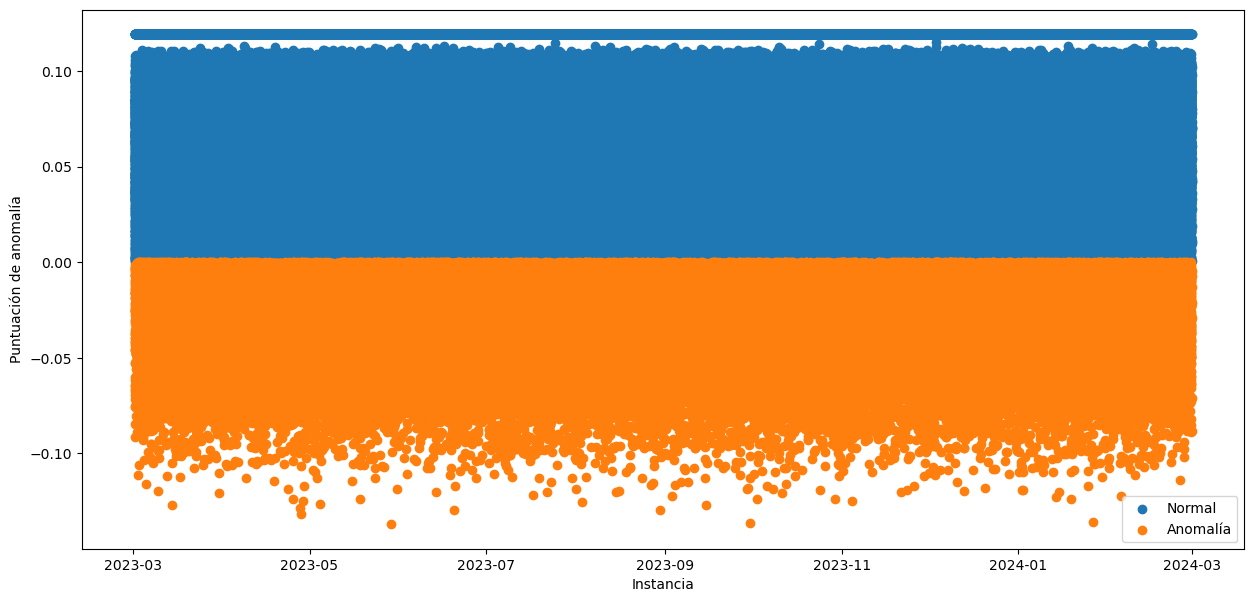

In [10]:
# Visualization of the results
plt.figure(figsize=(15, 7))

# Plot normal instances
normal = df2_agrupado[df2_agrupado['anomaly'] == 1]
plt.scatter(normal['timestamp'], normal['anomaly_score'], label='Normal')

# Plot anomalies
anomalies = df2_agrupado[df2_agrupado['anomaly'] == -1]
plt.scatter(anomalies['timestamp'], anomalies['anomaly_score'], label='Anomalía')

plt.xlabel("Instancia")
plt.ylabel("Puntuación de anomalía")
plt.legend()
plt.show()


### KernelSHAP

In [33]:
df_limpio = df2_agrupado.select_dtypes(include=['number']).astype('float64')

# explainer = shap.Explainer(iso_forest, df_limpio) 


# Seleccionar al azar n instancias normales, y todas las n de anomalías
normal_sample = np.random.choice(normal.index,size=850,replace=False)
sample = np.append(anomalies.index,normal_sample)



# Tomar una sub-muestra de 1000 normales y 1000 anomalías para el gráfico
# Suponiendo que 'sample' son tus índices
sub_sample = np.random.choice(sample, 2000, replace=False)
# shap_values_sub = explainer(features.iloc[sub_sample])
print(f'samples principales: {len(sample)}')
print(f'sub_samples : {len(sub_sample)}')

samples principales: 88612
sub_samples : 2000


In [34]:
# Uso de la puntuación de anomalía y KernelSHAP

# explainer = shap.Explainer(iso_forest.decision_function, features)
# shap_values = explainer(features.iloc[sample])



# # Configura el explainer
# explainer = shap.Explainer(iso_forest.decision_function, features)

# # Define una función para procesar cada muestra
# def compute_shap(row):
#     return explainer(row)

# # Ejecuta en paralelo sobre tu selección de muestras (sample)
# # n_jobs=-1 usará todos tus núcleos
# shap_values_list = Parallel(n_jobs=-1)(
#     delayed(compute_shap)(features.iloc[[i]]) for i in sample
# )


# TreeExplainer es nativo para modelos de árboles y mucho más eficiente
explainer = shap.TreeExplainer(iso_forest)

# Calcula los valores para todo el subset de una vez
# shap_values = explainer(features.iloc[sample])
shap_values = explainer(features.iloc[sub_sample])

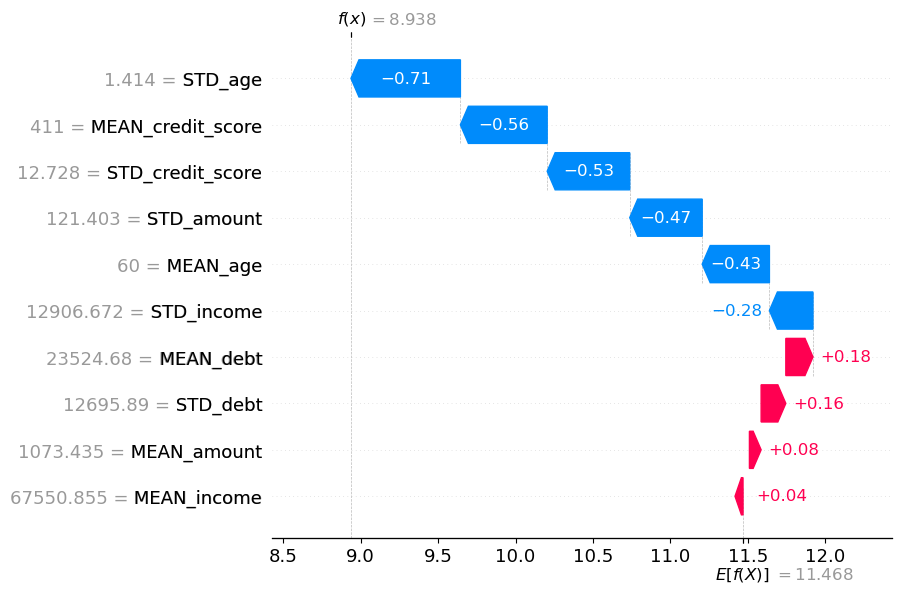

In [35]:
# Gráfico de cascada de una anomalía
shap.plots.waterfall(shap_values[0])

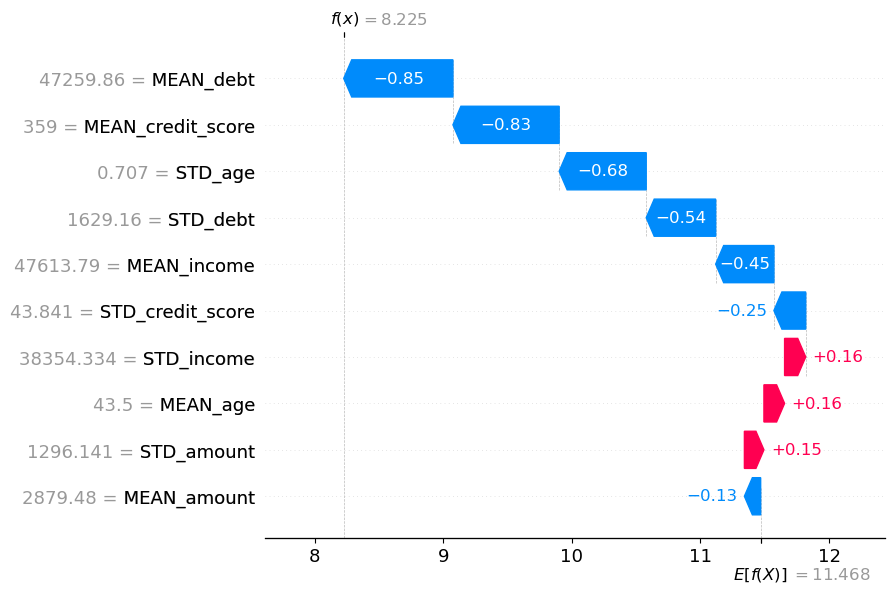

In [36]:
# Gráfico de cascada para una instancia normal
shap.plots.waterfall(shap_values[100])

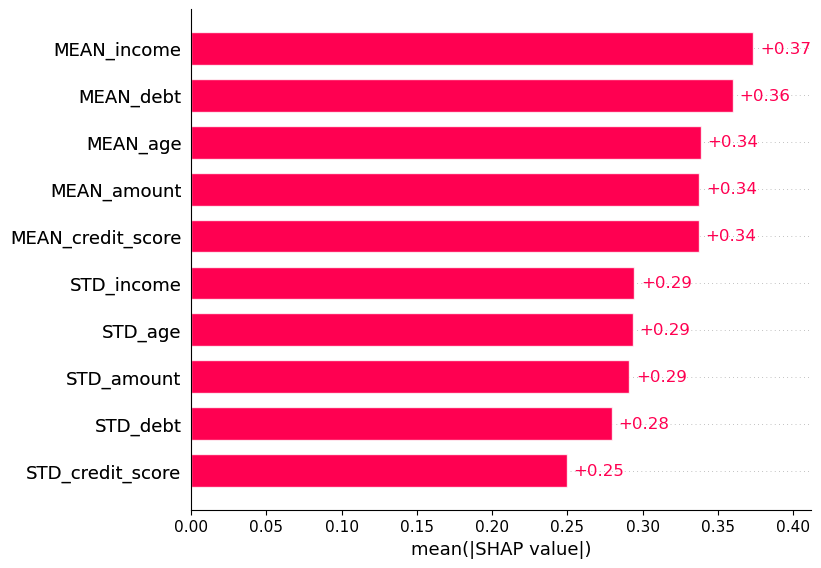

In [38]:
# Gráfico de medias de SHAP Plot
shap.plots.bar(shap_values)

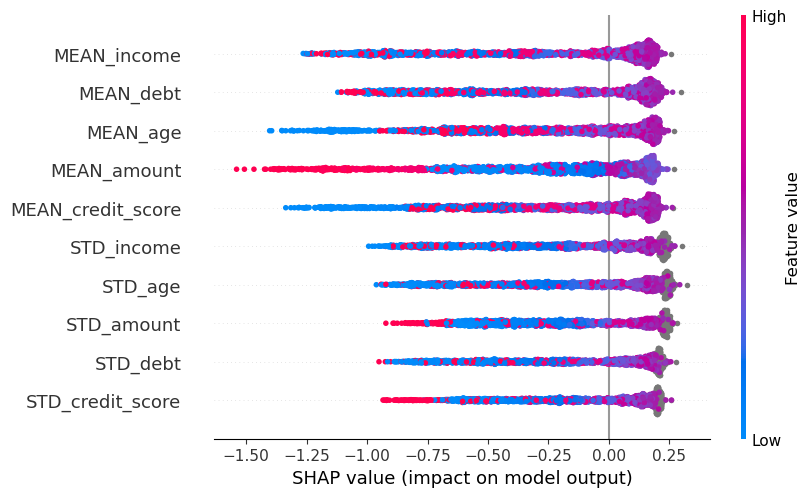

In [39]:
# Gráfico Beeswarm
shap.plots.beeswarm(shap_values)

In [40]:
df2_agrupado.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 525949 entries, 0 to 525948
Data columns (total 13 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   timestamp          525949 non-null  datetime64[ns]
 1   MEAN_amount        514226 non-null  float64       
 2   STD_amount         469662 non-null  float64       
 3   MEAN_age           514226 non-null  float64       
 4   STD_age            469662 non-null  float64       
 5   MEAN_income        514226 non-null  float64       
 6   STD_income         469662 non-null  float64       
 7   MEAN_debt          514226 non-null  float64       
 8   STD_debt           469662 non-null  float64       
 9   MEAN_credit_score  514226 non-null  float64       
 10  STD_credit_score   469662 non-null  float64       
 11  anomaly_score      525949 non-null  float64       
 12  anomaly            525949 non-null  int64         
dtypes: datetime64[ns](1), float64(11), int64(1)


In [41]:

df2_agrupado['anomaly'] = iso_forest.predict(features)

# valor de fraude real el el df
y_true = (df2_agrupado2['MEAN_is_fraud'] > 0).astype(int)

# Ajustar formato para evaluación: 1 para anomalía, 0 para normal
y_pred = [1 if x == -1 else 0 for x in df2_agrupado['anomaly']]

# Generar reporte (asumiendo que tienes 'y_true')
print(classification_report(y_true, y_pred, target_names=['Normal', 'Anomalía']))

              precision    recall  f1-score   support

      Normal       0.11      0.63      0.19     78485
    Anomalía       0.67      0.13      0.22    447464

    accuracy                           0.21    525949
   macro avg       0.39      0.38      0.21    525949
weighted avg       0.59      0.21      0.22    525949



In [42]:
print(y_true.value_counts())

MEAN_is_fraud
1    447464
0     78485
Name: count, dtype: int64
